# Stage 4 - Monitoring FIT EDA

Stage 4 extends the aggregate Garmin JSON case study with minute-level FIT monitoring records. This notebook checks whether that layer is interpretable enough to support public EDA and a future sleep-outcome modeling pass.

The goal is deliberately modest: understand inventory, quality, semantic-day behavior, and candidate feature families. This is exploratory EDA, not production prediction evidence.


## What Minute-Level FIT Adds

The aggregate JSON EDA can say that a day had a certain average stress level, resting heart rate, or next-night recovery score. The monitoring FIT layer adds a different resolution:

- intra-day HR/stress dynamics instead of daily summaries only
- sleep-aware windows rather than midnight-to-midnight grouping
- direct coverage, gap, and boundary diagnostics
- stress status semantics: numeric stress, unmeasurable/status values, and HR-confirmed active proxy minutes
- wake-quarter, sleep-quarter, and pre-sleep windows that become leakage-aware candidate predictors for Notebooks 08/09

That extra resolution is useful only if the quality layer is visible, so the notebook starts with inventory and filtering before interpreting patterns.


## Setup


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/wearable-analytics-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")


def show_figure(fig):
    display(fig)
    plt.close(fig)


ROOT = find_repo_root()
scripts_dir = ROOT / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

import run_stage4_monitoring_public_analysis as monitoring_eda

stage4 = monitoring_eda.load_stage4_monitoring_data(ROOT)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

print(f"Repository root: {ROOT}")


Repository root: /Users/abatrakov/Documents/FUN/wearable-analytics


## Data Inventory

First check that the expected monitoring contracts exist and line up on the same calendar span. This is the foundation: HR/stress minute rows, semantic sleep windows, quality rows, and the two feature tables.


In [2]:
inventory = monitoring_eda.monitoring_inventory(stage4)
stress_status = monitoring_eda.stress_status_counts(stage4)

display(inventory)
display(stress_status)


,table,rows,columns,date_range
0,monitoring_heart_rate,675325,3,2023-05-26 to 2026-05-18
1,monitoring_stress,889323,4,2023-05-26 to 2026-05-18
2,semantic_sleep_windows,556,15,2023-05-27 to 2026-05-18
3,monitoring_quality_index,589,88,2023-05-27 to 2026-05-18
4,monitoring_features_core_v0,589,93,2023-05-27 to 2026-05-18
5,monitoring_features_full_v0,589,243,2023-05-27 to 2026-05-18


,stress_status,rows
0,valid,674752
1,unmeasurable,214571


The inventory shows the multi-resolution shape of Stage 4: hundreds of semantic analysis windows built from hundreds of thousands of minute-level observations. Stress has both valid numeric values and unmeasurable/status rows, so treating the raw stress column as one continuous score would be misleading.


## Quality Funnel


The quality funnel turns observed sleep windows into analysis windows, then into recovery-modeling eligible rows. This keeps boundary plausibility and signal coverage separate from candidate model features.


,step,rows,share_of_analysis_rows
0,Observed semantic sleep windows,556,NaN
1,Analysis windows after boundary policy,589,1.000000
2,Rows with observed next sleep boundary,524,0.889643
3,Rows plausible under sleep/wake duration bounds,524,0.889643
4,Rows usable for sleep and wake HR/stress,481,0.816638
5,Rows eligible for recovery modeling v0,472,0.801358


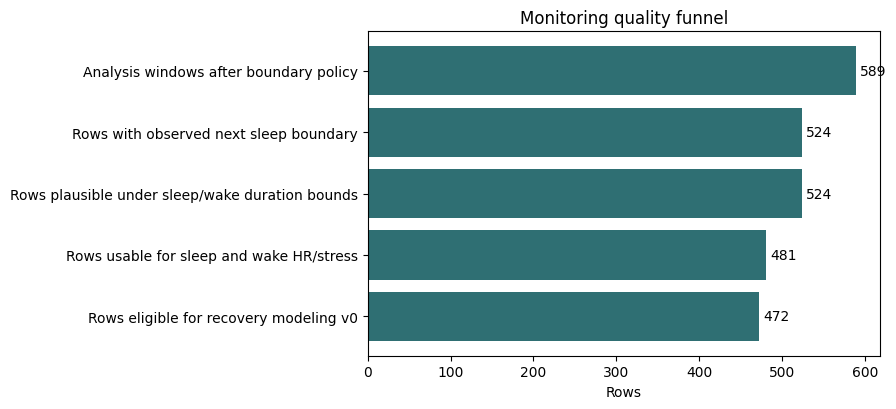

In [3]:
funnel = monitoring_eda.quality_funnel(stage4)
display(funnel)
fig = monitoring_eda.plot_quality_funnel(funnel)
show_figure(fig)


The largest drop is not from raw file decoding; it is from requiring plausible sleep/wake boundaries and usable whole sleep/wake HR and stress. That is the right failure mode for this layer: questionable windows stay visible instead of quietly becoming model rows.


## Quality Over Time


Minute-level quality is also temporal. A compact monthly view makes it clear why future modeling should keep a forward-looking holdout rather than treating all windows as exchangeable.


,month,analysis_rows,eligible_rows,wake_hr_usable_rows,wake_stress_usable_rows,missing_next_sleep,observed,observed_late_within_duration,synthetic_split,unsupported_multi_day_gap,eligible_rate
20,2025-08-01,26,19,21,21,0,22,0,2,2,0.730769
21,2025-09-01,23,18,18,18,0,18,0,2,3,0.782609
22,2025-10-01,23,20,20,20,0,20,0,2,1,0.869565
23,2025-11-01,21,14,14,14,0,15,0,5,1,0.666667
24,2025-12-01,6,3,3,3,0,3,0,1,2,0.500000
25,2026-01-01,31,26,26,26,0,27,0,4,0,0.838710
26,2026-02-01,28,23,25,25,0,24,0,4,0,0.821429
27,2026-03-01,31,21,23,23,0,23,0,8,0,0.677419
28,2026-04-01,25,18,18,18,0,19,0,4,2,0.720000
29,2026-05-01,12,6,6,6,1,7,0,2,2,0.500000


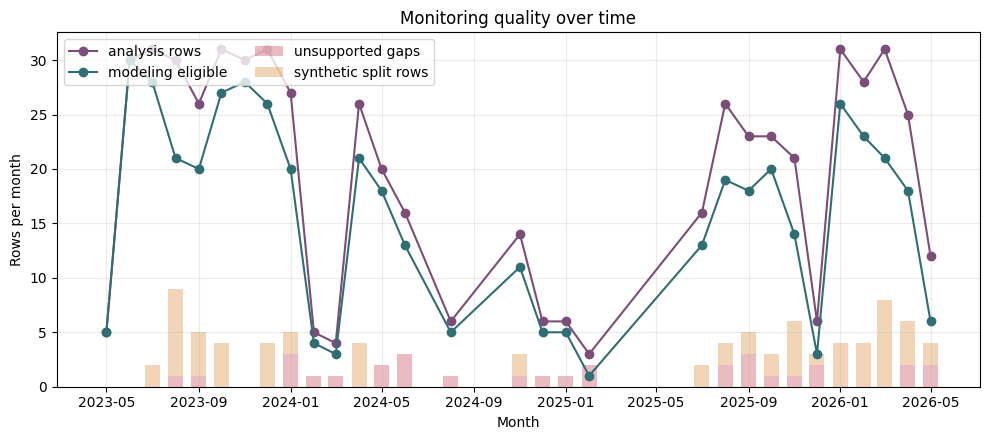

In [4]:
monthly_quality = monitoring_eda.monthly_quality_summary(stage4)
display(monthly_quality.tail(10))
fig = monitoring_eda.plot_quality_over_time(monthly_quality)
show_figure(fig)


The split and unsupported-gap rows are not evenly distributed over time. That matters because a model trained on one period may face different boundary and coverage conditions later.


## Coverage And Boundary Diagnostics


Coverage distributions are more readable than a wall of diagnostics. The key question is whether the sleep and wake windows have enough observed HR/stress minutes to support interpretation.


,phase,signal,metric,count,median,p10,p90
0,sleep,HR,Sleep HR,556,0.695396,0.617795,0.752368
1,sleep,stress,Sleep stress,556,0.975219,0.906419,0.997972
2,wake,HR,Wake HR,557,0.874684,0.610950,0.902817
3,wake,stress,Wake stress,557,0.916084,0.654996,0.961789


,boundary_confidence,rows
0,observed,490
1,synthetic_split,66
2,unsupported_multi_day_gap,31
3,observed_late_within_duration,1
4,missing_next_sleep,1


,flag,rows
0,sleep_hr_usable,552
1,sleep_stress_usable,553
2,wake_hr_usable,491
3,wake_stress_usable,491
4,pre_sleep_4h_usable,498
5,wake_quarters_usable,454
6,modeling_recovery_v0_eligible,472


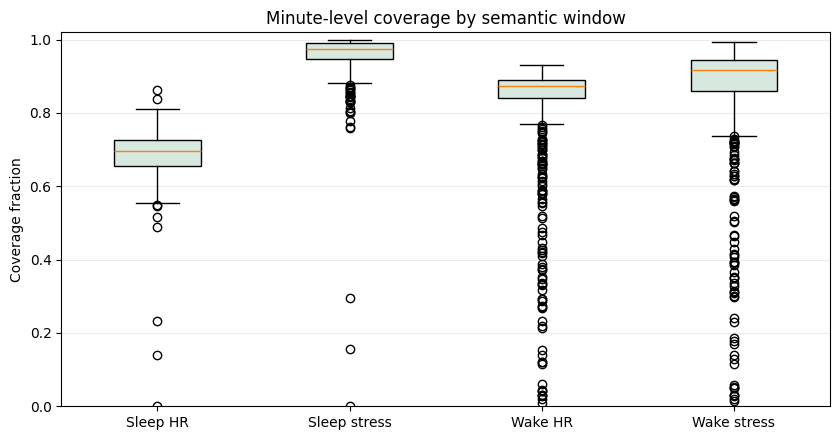

In [5]:
coverage = monitoring_eda.coverage_long(stage4)
coverage_summary = monitoring_eda.coverage_summary(stage4)
boundaries = monitoring_eda.boundary_counts(stage4)
usable_flags = monitoring_eda.usable_flag_counts(stage4)

display(coverage_summary)
display(boundaries)
display(usable_flags)
fig = monitoring_eda.plot_coverage_distributions(coverage)
show_figure(fig)


Sleep stress coverage is generally strong, while wake HR/stress coverage is more variable. That variability is exactly why the quality index remains a joinable table rather than being mixed into the feature table.


## Monitoring Day Browser


The day browser is the main sanity check for the monitoring layer. It shows one semantic day from sleep start through wake end, with HR and stress plotted at minute resolution.

Change `SELECTED_MONITORING_DATE` and rerun the next two cells to inspect another day. Set it to `None` to auto-pick a high-coverage eligible day.


In [6]:
SELECTED_MONITORING_DATE = "2026-02-10"
IMPERFECT_MONITORING_DATE = None  # Example: "2026-05-09" to inspect a known unsupported-gap row.
DISPLAY_TIMEZONE = "Europe/Berlin"


,metric,value
0,selected_date,2026-02-10
1,analysis_window_id,2026-02-10_0479_observed
2,boundary_confidence,observed
3,modeling_recovery_v0_eligible,1
4,HR rows in window,1199
5,stress rows in window,1464
6,valid numeric stress rows,1267
7,active proxy rows,149
8,unmeasurable -2 rows without HR,11
9,unmeasurable -1 rows,37


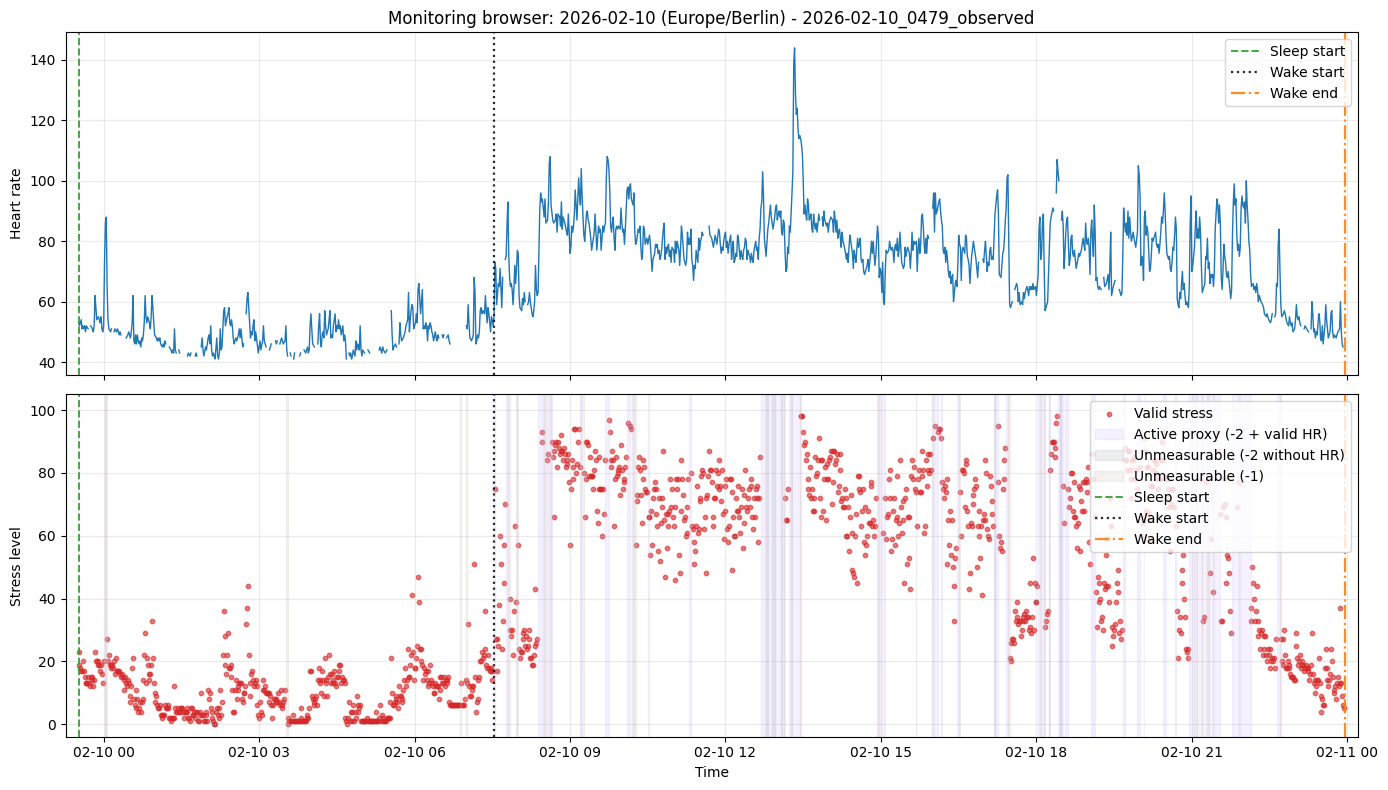

In [7]:
selected_window = monitoring_eda.choose_analysis_window(stage4.quality, SELECTED_MONITORING_DATE)
browser = monitoring_eda.prepare_day_browser_data(stage4, selected_window)

display(browser["summary"])
fig = monitoring_eda.plot_day_browser(browser, display_timezone=DISPLAY_TIMEZONE)
show_figure(fig)

if IMPERFECT_MONITORING_DATE is not None:
    imperfect_window = monitoring_eda.choose_analysis_window(stage4.quality, IMPERFECT_MONITORING_DATE)
    imperfect_browser = monitoring_eda.prepare_day_browser_data(stage4, imperfect_window)
    display(imperfect_browser["summary"])
    imperfect_fig = monitoring_eda.plot_day_browser(imperfect_browser, display_timezone=DISPLAY_TIMEZONE)
    show_figure(imperfect_fig)


In this example, the sleep start, wake start, and wake end markers define the semantic day. HR and numeric stress mostly move together during active daytime periods, while the translucent stress spans show status values that would disappear or be misread in a daily aggregate. The active proxy is a motion/status proxy rather than a numeric stress bin; it appears only when same-minute valid HR supports active or large-motion context.


## Representative Day Gallery


The selector above is still the detailed inspection tool. The gallery below auto-selects a few representative semantic windows so the notebook also shows multiple monitoring regimes without editing constants.

The examples are selected from the quality and feature tables: a high-coverage eligible reference day, an eligible day with high wake stress-state/elevated-HR-zone signal, and an imperfect boundary or non-eligible quality case when one has a complete display window.


,gallery_label,calendarDate,analysis_window_id,boundary_confidence,modeling_recovery_v0_eligible,coverage_score,largest_gap_minutes,selection_reason
0,high_quality_reference,2026-02-15,2026-02-15_0483_observed,observed,1,0.915055,8.0,Observed eligible window with high combined HR...
1,high_wake_load,2023-11-04,2023-11-04_0148_observed,observed,1,0.840160,18.0,Eligible window with high wake stress-state an...
2,imperfect_gap_or_boundary,2023-09-06,2023-09-06_0095_split_a,synthetic_split,0,0.896876,13.0,Non-observed or non-eligible window that keeps...


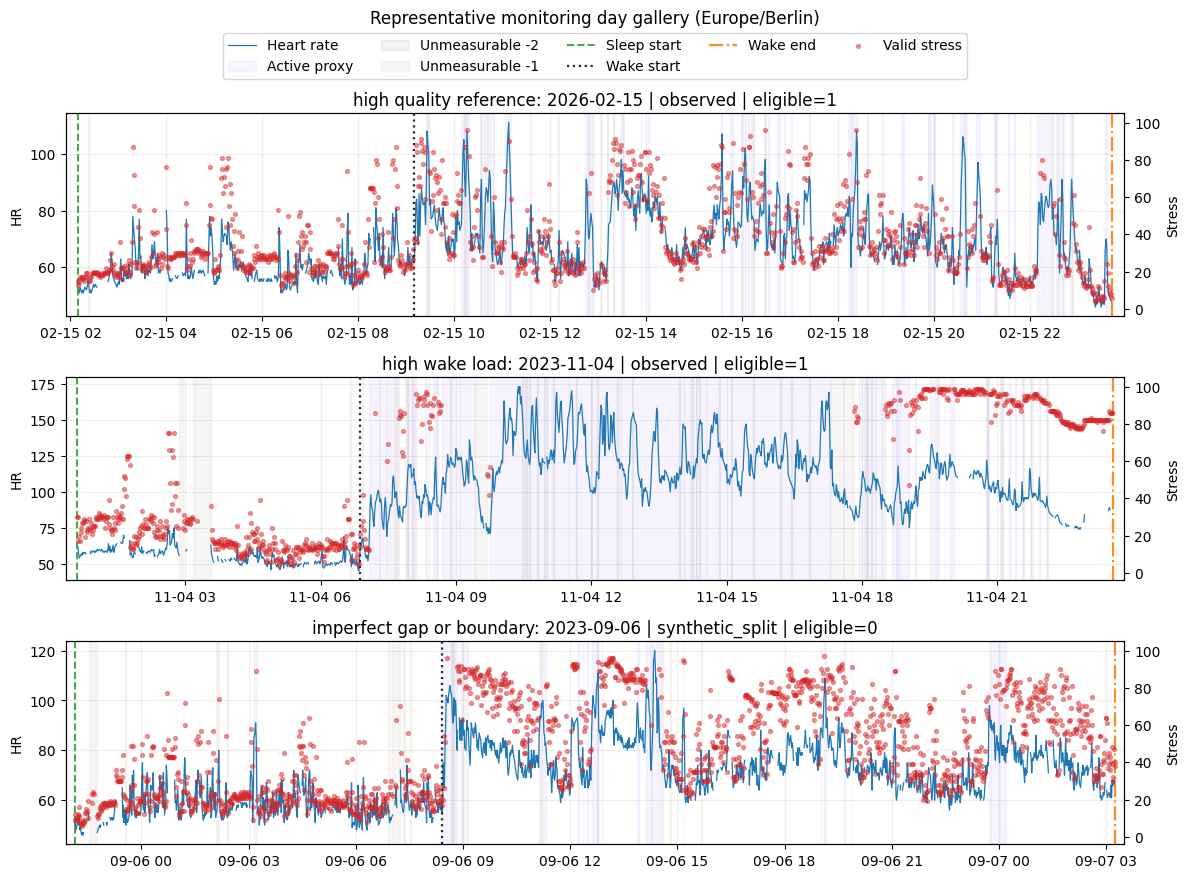

In [8]:
gallery = monitoring_eda.select_representative_day_gallery(stage4)
display(gallery)
fig = monitoring_eda.plot_day_gallery(stage4, gallery, display_timezone=DISPLAY_TIMEZONE)
show_figure(fig)


The gallery is intentionally compact. Its job is to make the quality system tangible: observed and imperfect boundaries, gaps in HR traces, valid stress points, and status-value spans can be seen in context. A daily JSON aggregate could summarize a day, but it could not show where those signals appeared inside the semantic window.


## Stress States And HR Zones


The feature layer summarizes wake stress as a composition of interpretable states. The active proxy is kept separate from numeric stress bins, which helps avoid turning motion/status minutes into stress-score claims.


,state,mean_fraction,median_fraction,p25,p75
0,resting,0.119298,0.087157,0.033958,0.175820
1,low,0.222491,0.219255,0.142477,0.301878
2,medium,0.234643,0.229129,0.175909,0.283944
3,high,0.227463,0.208118,0.117813,0.311444
4,active,0.196106,0.187949,0.135687,0.240272


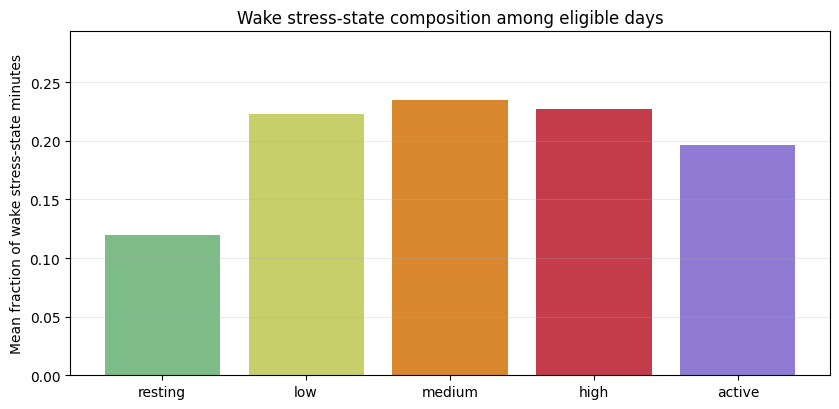

,zone,mean_fraction,median_fraction
0,below zone1,0.860112,0.882419
1,zone1,0.109996,0.090647
2,zone2,0.023265,0.013899
3,zone3,0.005459,0.001142
4,zone4,0.001056,0.000000
5,zone5,0.000112,0.000000
6,above mhr,0.000000,0.000000


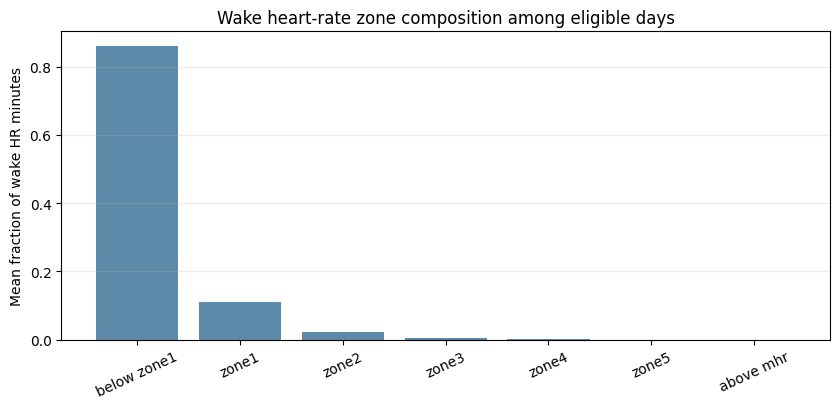

In [9]:
stress_state_summary = monitoring_eda.stress_state_summary(stage4)
hr_zone_summary = monitoring_eda.hr_zone_summary(stage4)

display(stress_state_summary)
fig = monitoring_eda.plot_stress_state_composition(stress_state_summary)
show_figure(fig)

display(hr_zone_summary)
fig = monitoring_eda.plot_hr_zone_composition(hr_zone_summary)
show_figure(fig)


Stress states and HR zones complement each other. Stress composition describes Garmin's numeric/status signal, while HR zones provide a separate view of physiological load and activity intensity.


## Within-Window Shape: Wake And Sleep Quarters


Minute-level data also adds shape. Wake quarters ask how HR and stress change across the daytime window; sleep quarters ask whether the same signals tend to settle across the night. These are descriptive summaries, not sleep-stage detection.


### Wake local-time distribution

Quarter summaries show that late wake tends to be lower, but they do not tell us whether that change is gradual or tied to a clock-time window. The next figure uses all recovery-eligible wake minute points, plotted by local clock time. After-midnight wake minutes are shown as `24+` so late evenings remain continuous.


,signal,points,windows,median_value
0,Heart rate,378828,472,76.0
1,Stress,319529,472,58.0


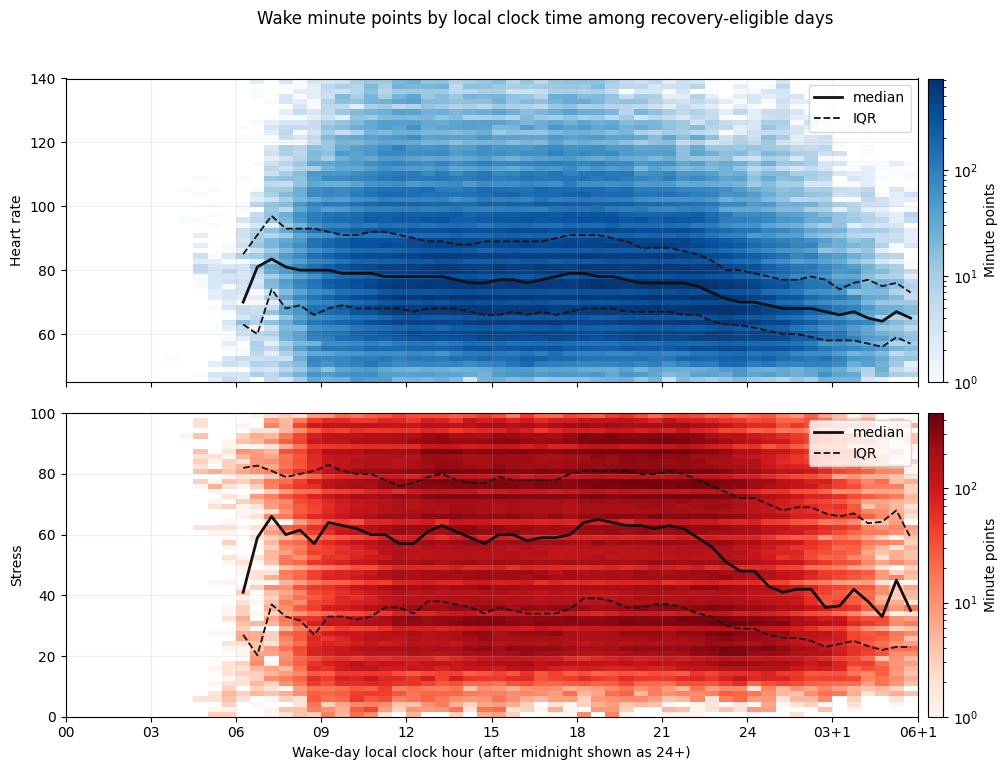

In [10]:
wake_time_points = monitoring_eda.wake_local_time_points(stage4)
wake_time_overview = (
    wake_time_points.groupby("signal", as_index=False)
    .agg(points=("value", "count"), windows=("analysis_window_id", "nunique"), median_value=("value", "median"))
    .sort_values("signal")
)
display(wake_time_overview)
fig = monitoring_eda.plot_wake_local_time_distributions(wake_time_points)
show_figure(fig)


Read this as descriptive EDA: the darker bins show where minute points concentrate, while the median/IQR line shows the typical signal level at that local time. If the evening drop is real in this dataset, it should appear as a downward bend in both HR and numeric stress before the next sleep boundary.


### Wake phase-fraction distribution

Clock time can mix different wake durations. This version maps each wake window to `[0, 1]`, so early wake, mid wake, and late wake line up even when the day starts or ends at different times.


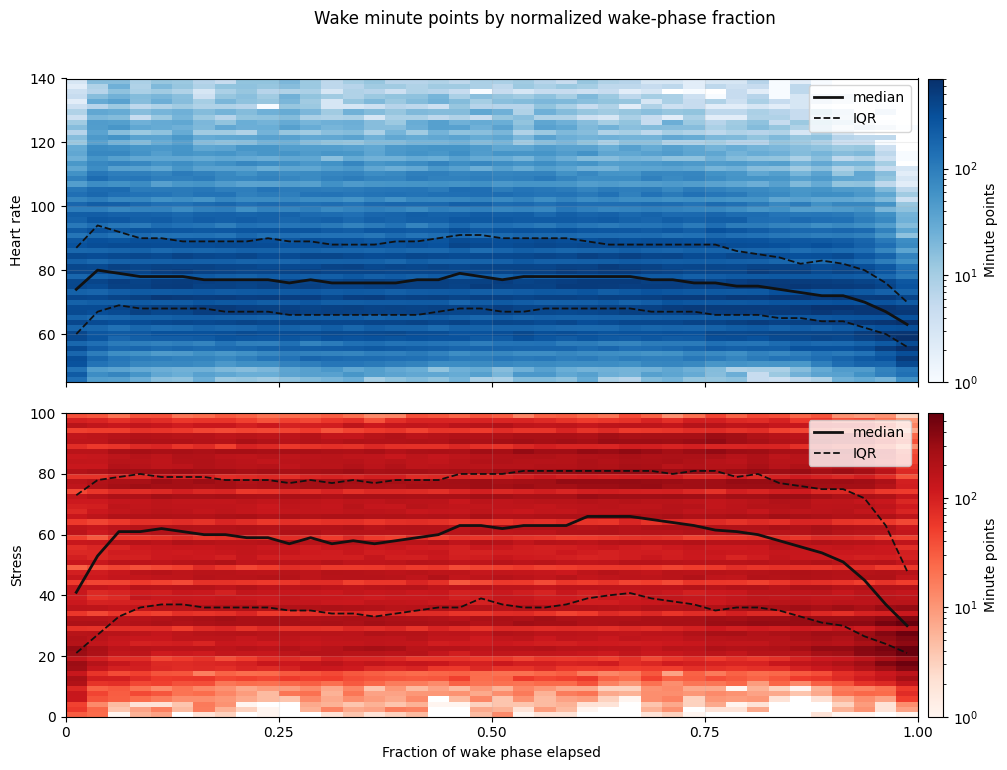

In [11]:
fig = monitoring_eda.plot_wake_phase_fraction_distributions(wake_time_points)
show_figure(fig)


This view tests whether the drop is a relative late-wake pattern rather than only a local-clock pattern. If both views slope down late, that is a stronger descriptive signal that the monitoring layer is capturing an evening/late-wake settling pattern.


### Wake stress distributions by quarter

The phase-fraction view suggests that the middle wake band may mix different stress regimes. Density-normalized histograms make that easier to inspect by comparing the numeric stress distribution in each normalized wake quarter.


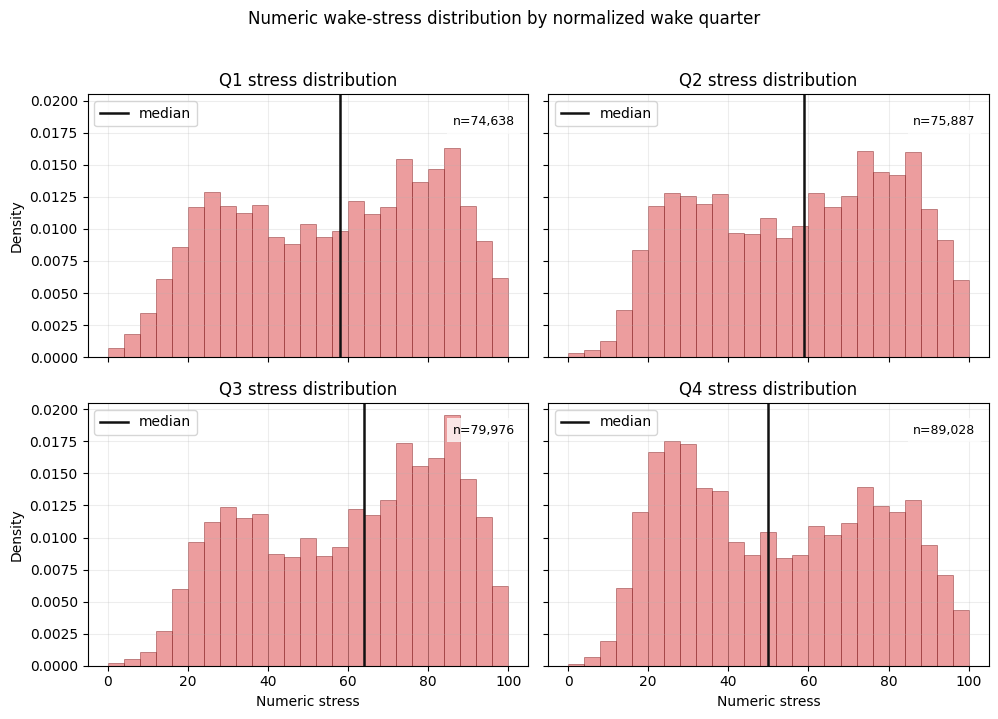

In [12]:
fig = monitoring_eda.plot_wake_stress_quarter_distributions(wake_time_points)
show_figure(fig)


Read these histograms as shape comparisons, not as separate outcome classes. If a quarter is bimodal, the density should show two stress ranges with visible mass rather than one broad mound.


### Wake quarters

Wake-quarter summaries keep the same recovery-eligible filter used by the modeling frame. A lower Q4 HR/stress pattern can be read as evening deactivation or rest in this EDA context, without turning it into a production prediction claim.


,phase,quarter,signal,rows,mean_value,median_value,p25,p75
0,wake,Q1,Heart rate,472,79.527576,78.245287,72.165188,86.260628
1,wake,Q1,Stress,472,56.884706,56.754528,45.708777,68.285384
2,wake,Q2,Heart rate,472,79.192105,78.492295,71.102041,87.124908
3,wake,Q2,Stress,470,58.454177,59.055195,45.593295,72.765885
4,wake,Q3,Heart rate,472,79.119564,78.953520,70.596724,86.642223
5,wake,Q3,Stress,472,61.379214,63.144594,48.253519,75.024516
6,wake,Q4,Heart rate,472,73.259914,72.522487,66.782169,78.963386
7,wake,Q4,Stress,472,52.210084,51.843207,39.924748,64.427976


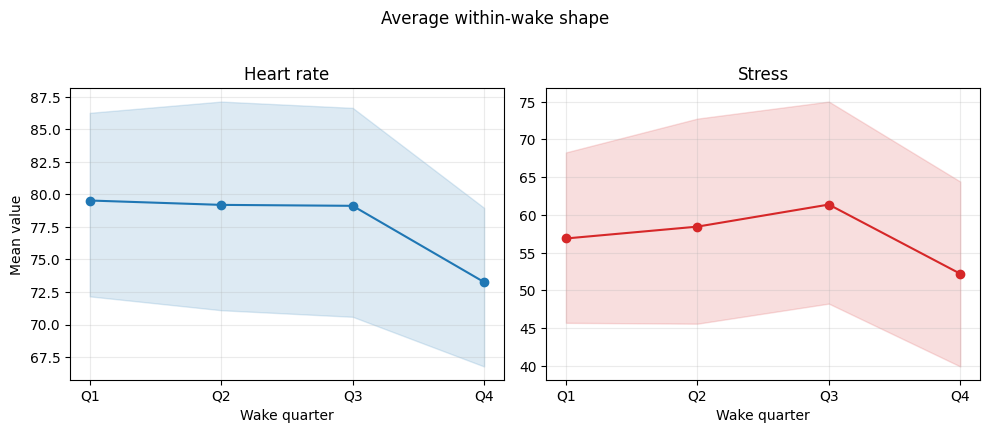

In [13]:
wake_shape = monitoring_eda.wake_quarter_shape(stage4)
display(wake_shape)
fig = monitoring_eda.plot_wake_quarter_shape(wake_shape)
show_figure(fig)


### Sleep quarters

Sleep-quarter summaries use plausible semantic windows with usable sleep HR and stress coverage. They show how HR and stress behave across the observed sleep window, but they do not identify sleep stages or health-state interpretation.


,phase,quarter,signal,rows,mean_value,median_value,p25,p75
0,sleep,Q1,Heart rate,520,54.652306,53.821828,50.593229,58.013505
1,sleep,Q1,Stress,520,20.048893,17.960035,13.361868,25.086120
2,sleep,Q2,Heart rate,520,51.683489,51.208093,48.321071,54.092575
3,sleep,Q2,Stress,520,14.670528,13.563490,8.603947,18.679442
4,sleep,Q3,Heart rate,520,50.402584,49.800000,47.580961,52.357861
5,sleep,Q3,Stress,520,12.132841,10.659994,7.509557,15.207119
6,sleep,Q4,Heart rate,520,50.530473,49.912355,48.087370,52.516667
7,sleep,Q4,Stress,520,11.872231,10.903234,7.861611,14.775941


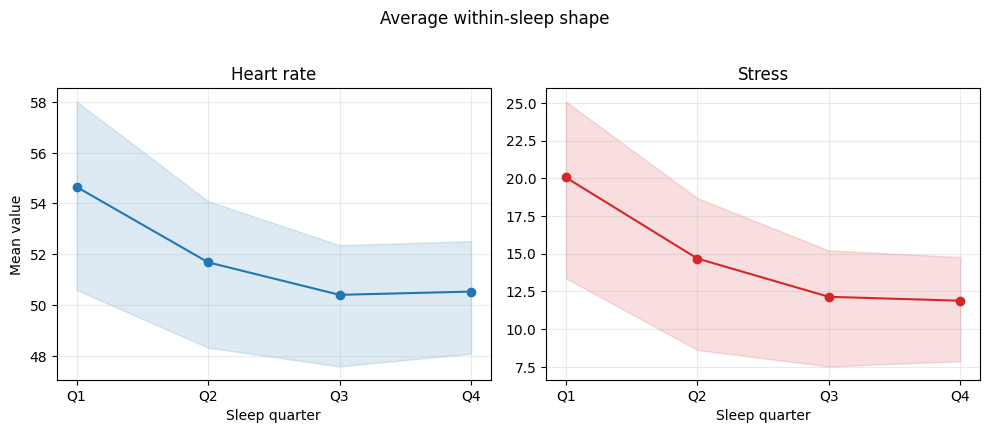

In [14]:
sleep_shape = monitoring_eda.sleep_quarter_shape(stage4)
display(sleep_shape)
fig = monitoring_eda.plot_sleep_quarter_shape(sleep_shape)
show_figure(fig)


Together, wake and sleep quarters show what the minute-level layer contributes beyond daily means: the feature table can preserve early, middle, and late window shape while keeping the quality filter explicit.


## Pre-Sleep Window


The pre-sleep four-hour window is the clearest bridge from EDA to next-night sleep-outcome modeling. It captures the immediate lead-up to sleep without using current sleep-phase features as predictors.


,metric,value
0,eligible rows,472.000000
1,pre_sleep_4h_usable rows,464.000000
2,pre_sleep_4h_hr_mean,72.906578
3,pre_sleep_4h_stress_mean,52.076501
4,pre_sleep_4h_hr_early_minus_late,9.051079
5,pre_sleep_4h_stress_early_minus_late,17.754220


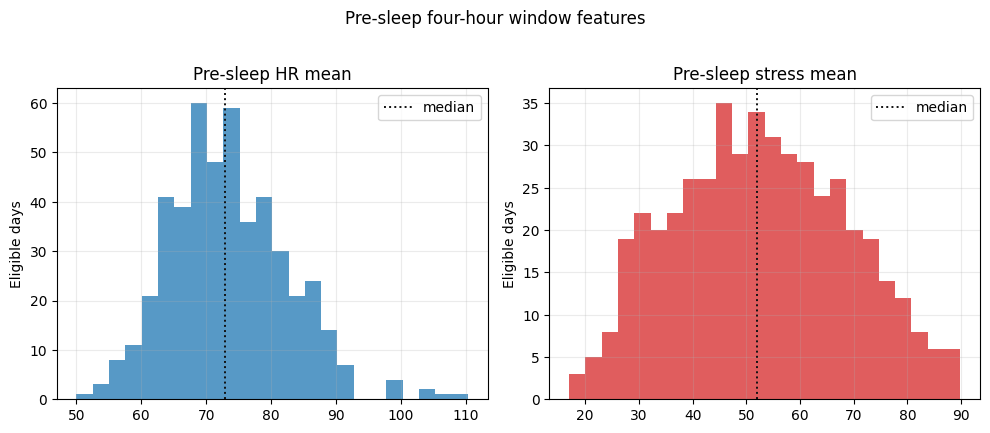

In [15]:
pre_sleep = monitoring_eda.pre_sleep_summary(stage4)
display(pre_sleep)
fig = monitoring_eda.plot_pre_sleep_window(stage4)
show_figure(fig)


Pre-sleep features are optional in the quality layer rather than mandatory for baseline eligibility. That keeps future modeling free to compare wake-only and wake-plus-pre-sleep feature sets without changing the row definition.


## Feature Readiness For Modeling


The EDA notebook ends by checking the feature catalog at a family level. Future modeling should still select predictors intentionally, but the table tells us what kinds of signals are available.


In [16]:
feature_shapes, family_counts = monitoring_eda.feature_table_overview(stage4)
display(feature_shapes)
display(family_counts)


,feature_table,rows,columns
0,core v0,589,93
1,full v0,589,243


,family,columns
0,distribution/shape,60
1,relative windows,56
2,episodes/state structure,35
3,variability/gaps,20
4,HR MHR zones,14
5,recovery/deactivation,14
6,HR/stress coupling,12
7,trends,12
8,stress state fractions,10
9,sleep-wake contrast,8


The core table is a compact starter set. The full table keeps a broader cleaned feature library, including distribution, state composition, variability, relative-window, trend, pre-sleep, and coupling families. Quality flags and coverage diagnostics remain outside the candidate feature tables.


## EDA Takeaways

- The minute-level FIT layer adds something the aggregate JSON EDA could not show: the shape and status semantics inside sleep/wake windows.
- Quality filtering is a first-class analytical result. Boundary confidence, wake duration plausibility, and HR/stress coverage decide which rows are safe to model.
- The day browser makes the semantic-window design tangible: sleep start, wake start, and wake end are visible on the same timeline as HR and stress.
- The representative gallery shows that those traces vary across high-quality, high-load, and imperfect-boundary examples, which daily aggregates would flatten.
- Raw stress status values need careful treatment. Numeric `0..100` stress, raw `-1`, and HR-confirmed raw `-2` active proxy minutes are different signals.
- Wake stress states, HR zones, wake quarters, sleep quarters, and pre-sleep summaries provide a leakage-aware bridge to future sleep-outcome modeling.
- Sleep-quarter summaries are descriptive monitoring features, not sleep-stage detection or diagnostic interpretation.
- This remains single-subject observational wearable data. The right public claim is a quality-aware monitoring feature layer, not production prediction performance.
